# Исследование метода k-ближайших соседей (KNN)

## 1. Загрузка + первичный анализ данных

В данной работе разбираем датасет Iris Species.
Он содержит:
- 150 объектов
- 4 числовых признака: длина чашелистика, ширина чашелистика, длина лепестка, ширина лепестка
- 3 класса растений

Источник: https://www.kaggle.com/datasets/uciml/iris

In [ ]:
import pandas as pd
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [ ]:
df = df.drop(columns=["Id"]) # нет полезной информации

In [ ]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df["Species"].value_counts() # глянем распределение классов

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Наблюдения
В датасете 150 строк, пропусков нет, все признаки числовые

Признаки имеют разные масштабы (ширина и длина лепестка сильно отличаются). Значит, нам потребуется масштабирование

Классы сбалансированы: по 50 объектов каждого класса. Значит модель не будет смещена в сторону одного класса, что хорошо

## 2. Подготовка данных
Разделим данные на обучающую и тестовую выборки и масштабируем признаки

**Разделение на traintest**

Модель должна обучаться на одной части данных(train), а проверяться на другой(test). Это нужно чтобы оценить, как модель работает на новых данных и избежать переобучения. Нельзя подбирать параметры модели на тестовой выборке, иначе оценка качества будет необъективной(data leakage).

**Масштабирование признаков**

KNN использует расстояние между объектами. Если признаки имеют разные масштабы то один признак может вложить больше вклада в расстояние чем другие. Без масштабирования модель будет работать некорректно, поэтому признаки приводим к одному масштабу.

### 2.1 Разделение данных

In [ ]:
from sklearn.model_selection import train_test_split
# признаки, целевая переменная - species
X = df.drop(columns=["Species"])
y = df["Species"]
# деление на train и test
# 20% на тест, магическое число для воспроизводимости, сохранение пропорций классов(чтобы были представлены все классы)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape # проверка размеров

((120, 4), (30, 4))

### 2.2 Масштабирование данных
Используем StandardScaler(Z стандартизацию). Так мы приведем все признаки к одинаковому масштабу. Scaler обучается только на train данных, а применяется к test.

Нельзя подбирать параметры модели на тестовой выборке, иначе оценка качества будет необъективной(data leakage).

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # обучаем только на train
X_test_scaled = scaler.transform(X_test) # применяем к test

## 3. Обучение KNN

### 3.1 KNN без масштабирования
Исходные данные без масштабирования. Используем k=5(значение по умолчанию) и евклидово расстояние.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=5) # модель (экземпляр)
knn.fit(X_train, y_train) # ленивое обучение (запоминание)
y_pred = knn.predict(X_test) # предсказания
accuracy_no_scale = accuracy_score(y_test, y_pred)
accuracy_no_scale # оценка качества без z преобразования

1.0

### 3.2 KNN с масштабированием
Это будет лучше для KNN так как расстояния считаются честно между признаками.

In [ ]:
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
accuracy_scaled

0.9333333333333333

### 3.3 Сравнение и вывод
точность после масштабирования упала?!?!? (с 1.0 до 0.93) скорее всего малый размер тестовой выборки а ошибка даже в 2-х точках дает заметное падение процента. признаки ирисок изначально имеют один масштаб в см, поэтому StandardScaler не дает здесь такого же эффекта как на данных с разными единицами измерения. короче не моя вина. в любом случае:

Масштабирование влияет на качество модели, потому что KNN использует расстояния: признаки с большим диапазоном влияют больше а другие признаки игнорируются, а после масштабирования их вклад уравнивается. Итого масштабирование является обязательным шагом для KNN

## Более глубокая оценка
Одной accuracy недостаточно для полного понимания модели.

Рассмотрим: confusion matrix(матрица несоответствий), precision(точность), recall(полнота), f1-score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



### Наблюдения
С их помощью мы можем понять где именно модель ошиблась


Модель немного путает Iris-versicolor и Iris-virginica, в то время как Iris-setosa распознает безошибочно. У Iris-virginica полнота=0.80, так как модель потеряла 2 реальных объекта этого класса, а у Iris-versicolor точность=0.83, так как в этот класс ошибочно загнали обьекты другого класса.

## 4. Обучение KNN
### 4.1 Влияние числа соседей k
k маленьное -> модель чувствительна(переобучение)

k большое -> модель сглаженна(недообучение)

In [ ]:
from sklearn.metrics import accuracy_score
k_values = range(1, 21)
accuracies = [] # результаты
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
accuracies

[0.9666666666666667,
 0.9333333333333333,
 0.9333333333333333,
 0.9333333333333333,
 0.9333333333333333,
 0.9333333333333333,
 0.9666666666666667,
 0.9333333333333333,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9333333333333333,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667,
 0.9666666666666667]

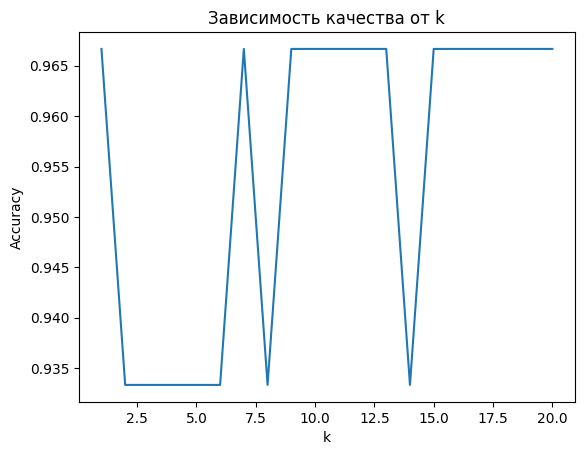

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(k_values, accuracies)
plt.title("Зависимость качества от k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

### Наблюдения

Очень точная модель при k=1, но это скорее всего повезло. Есть провалы при k=8 и k=14. От k=15 зависимость стабильная. Можем сказать что существует оптимальное значение k

**Вывод:** k надо подбирать. здесь лучший выбор k=17, модель не будет дергаться изза какой нибудь случайной точки

### 4.2 Влияние параметра weights
Как учитывать соседей: все равны(uniform) или ближние важнее(distance)

In [ ]:
results_weights = {}
for w in ["uniform", "distance"]:
    model = KNeighborsClassifier(n_neighbors=5, weights=w)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled) # масштабируемые!!!
    acc = accuracy_score(y_test, y_pred)
    results_weights[w] = acc # метод + точность
results_weights

{'uniform': 0.9333333333333333, 'distance': 0.9666666666666667}

### Наблюдения
distance работает лучше, т. к. ближайшие соседи более информативны. Это будет полезно при шумных данных

### 4.3 Влияние метрики расстояния
Метрика определяет, как считается расстояние между объектами. Рассмотрим Euclidean, Manhattan, Minkowski

In [ ]:
metrics = ["euclidean", "manhattan", "minkowski"]
results_metrics = {}
for m in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=m)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results_metrics[m] = acc
results_metrics

{'euclidean': 0.9333333333333333,
 'manhattan': 0.9333333333333333,
 'minkowski': 0.9333333333333333}

### Наблюдения
Одинаковые результаты: датасет мал и прост. 

**Вывод:** важными здесь оказались масштабирование и подбор k

## 5. Подбор гиперпараметров
Ранее параметры подбирали вручную. Теперь мы будем использовать GridSearchCV.

### Кросс-валидация
Способ более надежной оценки модели. Данные делятся на несколько частей(folds). Даёт более стабильную оценку, чем одно разбиение train-test

### Настройка параметров для перебора
Будем подбирать: n_neighbors, weights, metric

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}
knn = KNeighborsClassifier()
# модель + словарь + фолды + успех=точность + все ядра процессора
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [ ]:
grid_search.best_params_  # После перебора глянем лучшие найденные параметры:

{'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}

In [ ]:
grid_search.best_score_ # наилучший результат точности 

np.float64(0.975)

Теперь проверим лучшую модель на test. Он не использовался при обучении, так что оценка честная

In [ ]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
accuracy_best

0.9666666666666667

### Сравнение результатов
Базовая модель(без настройки)=0.9333, модель после GridSearch=0.9666;
Высокая точность связана с тем, что классы хорошо разделимы в пространстве признаков, поэтому ближайшие соседи чаще принадлежат тому же классу

### Вывод
Подбор гиперпараметров улучшает качество модели, т. к. позволяет найти более подходящую конфигурацию под данные.

### Почему нельзя подбирать параметры вручную

Ручной подбор субъективен и не гарантирует оптимального результата.
GridSearchCV системно перебирает параметры и использует кросс-валидацию. Так мы получим более надежный результат

## 6. Выводы
В данной работе был исследован метод k-ближайших соседей на датасете Iris.

Масштабирование признаков оказалось критически важным: без него качество модели стало ниже. Параметр k существенно влияет на модель. Параметр weights: использование distance дало лучший результат. Метрика расстояния влияет на качество, но не так сильно как k. GridSearchCV позволил найти оптимальные параметры и улучшил качество модели